# ArXiv Dataset Exploration

## Notebook Imports

In [12]:
from datasets import load_dataset, load_from_disk
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
import numpy as np
import pandas as pd
from pprint import pprint

%load_ext autoreload
%autoreload 2

from arxiv_paper_discovery.config import RAW_DATA_PATH, BASE_DATA_PATH, PROCESSED_DATA_DIR
from arxiv_paper_discovery.utils import compute_label_coverage

## Raw Dataset

In [2]:
RAW_DATA_PATH

PosixPath('/home/dhiran/projects/arxiv-paper-discovery/data/raw/arxiv/arxiv-metadata-oai-snapshot.json')

In [6]:
raw_dataset_json = load_dataset(
    "json",
    data_files=str(RAW_DATA_PATH),
    split="train",
)

print(f"No of samples: {len(raw_dataset_json)}")
print(f"Columns : {raw_dataset_json.column_names}")

No of samples: 2982054
Columns : ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed']


## Base Dataset

In [7]:
base_dataset = load_from_disk(BASE_DATA_PATH)

In [17]:
print(base_dataset)
pprint(base_dataset[0])

Dataset({
    features: ['id', 'title', 'abstract', 'categories', 'authors', 'update_date'],
    num_rows: 2982054
})
{'abstract': 'A fully differential calculation in perturbative quantum '
             'chromodynamics is presented for the production of massive photon '
             'pairs at hadron colliders. All next-to-leading order '
             'perturbative contributions from quark-antiquark, '
             'gluon-(anti)quark, and gluon-gluon subprocesses are included, as '
             'well as all-orders resummation of initial-state gluon radiation '
             'valid at next-to-next-to-leading logarithmic accuracy. The '
             'region of phase space is specified in which the calculation is '
             'most reliable. Good agreement is demonstrated with data from the '
             'Fermilab Tevatron, and predictions are made for more detailed '
             'tests with CDF and DO data. Predictions are shown for '
             'distributions of diphoton pairs prod

In [21]:
base_dataset["categories"]

Column([['hep-ph'], ['math.CO', 'cs.CG'], ['physics.gen-ph'], ['math.CO'], ['math.CA', 'math.FA'], ...])

### Label Distribution

In [ ]:
counter = Counter()

for labels in tqdm(base_dataset["categories"], desc="Counting labels"):
    counter.update(labels)

label_df = pd.DataFrame(counter.items(), columns=["label", "count"])
label_df = label_df.sort_values(by="count", ascending=False).reset_index(drop=True)
label_df.to_csv("../outputs/analysis/base_label_distribution.csv", index=False)

label_df.head()

Counting labels: 100%|██████████| 2982054/2982054 [00:31<00:00, 94575.39it/s] 


,label,count
0,cs.LG,257067
1,hep-ph,194395
2,cs.CV,184612
3,hep-th,180625
4,quant-ph,175671


In [23]:
# Top 10 and bottom 10 labels
top10 = label_df.head(10).reset_index(drop=True)
bottom10 = label_df.tail(10).reset_index(drop=True)
side_by_side = pd.concat([top10, bottom10], axis=1, keys=["Top 10", "Bottom 10"])
side_by_side

Top 10         Bottom 10      
               label   count     label count
0              cs.LG  257067   mtrl-th   262
1             hep-ph  194395   chem-ph   251
2              cs.CV  184612     cs.GL   229
3             hep-th  180625  comp-gas   221
4           quant-ph  175671  supr-con   175
5              cs.AI  166910   atom-ph   123
6              gr-qc  120089  acc-phys    49
7  cond-mat.mtrl-sci  107107  plasm-ph    38
8           astro-ph  105380    ao-sci    17
9              cs.CL  104104  bayes-an    16

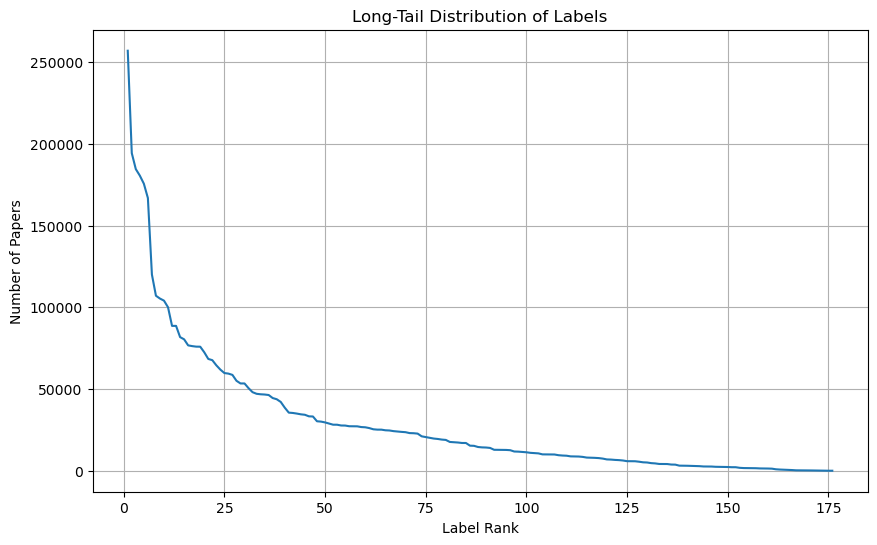

In [ ]:
# Plotting the long-tail distribution

counts = label_df["count"].values

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(counts)+1), counts)
plt.xlabel("Label Rank")
plt.ylabel("Number of Papers")
plt.title("Long-Tail Distribution of Labels")
plt.grid()

plt.savefig("../outputs/plots/base_long_tail.png", dpi=300)
plt.show()

### Stats for categories per paper

In [ ]:
num_categories_per_paper = [
    len(item["categories"]) 
    for item in tqdm(base_dataset, desc="Counting categories per paper")
]

print("\nStats for categories per paper:")
print(f"Average: {np.mean(num_categories_per_paper):.2f}")
print(f"Max: {np.max(num_categories_per_paper)}")
print(f"Min: {np.min(num_categories_per_paper)}")

Counting categories per paper: 100%|██████████| 2982054/2982054 [01:31<00:00, 32678.75it/s]



Stats for categories per paper:
Average: 1.72
Max: 13
Min: 1


### % of papers covered by top k labels

In [14]:
coverage, labels = compute_label_coverage(base_dataset)

Counting labels:   0%|          | 0/2982054 [00:00<?, ?it/s]

Computing coverage: 100%|██████████| 176/176 [00:20<00:00,  8.80it/s]


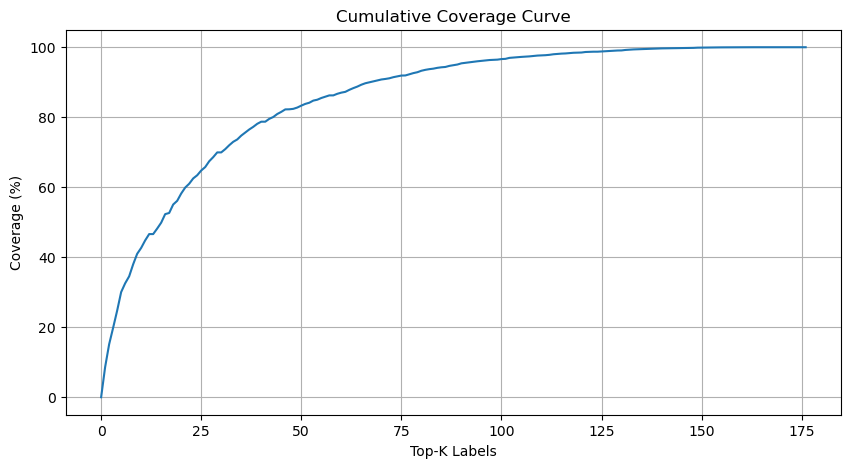

In [ ]:
plt.figure(figsize=(10, 5))
coverage_plot = [0] + coverage
x = range(len(coverage_plot))

plt.plot(x, coverage_plot)
plt.xlabel("Top-K Labels")
plt.ylabel("Coverage (%)")
plt.title("Cumulative Coverage Curve")
plt.grid()

plt.savefig("../outputs/plots/base_cumulative_coverage_curve.png", dpi=300)
plt.show()